# Predicting Seismic Building Drift with Support Vector Regression

**Hayden Willen** | DS 4021 Machine Learning II

This project predicts how much a building moves during an earthquake using real sensor recordings from instrumented buildings in the US and Japan. The target is Drift, the maximum drift ratio of a building, and the inputs are 41 features describing the building, the ground shaking, and the earthquake itself. It follows the approach in Tao et al. (2024), which used Support Vector Regression (SVR) to predict building response from the NDE1.0 database.

The notebook compares SVR with Ridge and Lasso regression, tests whether a smaller set of features can predict drift almost as well as the full set, and checks how stable each model is when the training data changes slightly.

**Reference.** Tao, D., Fang, S., Liu, H., et al. Support vector regression model for the prediction of buildings' maximum seismic response based on real monitoring data. *Sci Rep* 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3


## 1. Background and SVR Theory

a. Questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

Predicting how buildings respond to earthquakes matters because building damage is what actually hurts people. When strong shaking damages or collapses a building, it leads to injuries and deaths, property damage, and buildings that can't be used anymore. The paper points out that in the US alone, shaking damage to buildings causes about $14.7 billion in losses each year on average. The hard part is timing. Right after an earthquake, emergency teams need to know which buildings are most likely damaged so they can send rescuers to the right places, decide which buildings are safe to go back into, and estimate economic losses. A big city can have hundreds of thousands of buildings, and most of them are missing detailed design information, so inspecting all of them quickly isn't possible. A model that predicts a building's maximum drift ratio from the ground motion and basic building info gives a fast first estimate of where the damage is likely to be.

The NDE1.0 dataset fits a machine learning approach well for a few reasons. First, it is built from real recordings in instrumented buildings instead of computer simulations, which most earlier ML studies relied on. It is also large and varied, with 12,293 recordings from 147 buildings during 3,081 earthquakes in the US and Japan, covering steel, concrete, masonry and wood buildings. Each record comes with 41 features that describe the building, the response spectrum, the shaking duration and the earthquake itself, which gives a model a lot to learn from. Traditional physics-based methods need a detailed structural model of each building and a ground motion record at its base, and running those simulations takes too long for a quick response after an earthquake. Most earlier models built on NDE1.0 also used linear or log-linear regression, which can't capture how these features interact in nonlinear ways. An ML model like SVR can learn those relationships straight from the data. The tradeoff is that ML models need a lot of good data and are harder to interpret, but this dataset is big enough that the first issue isn't a major concern here.

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

SVR works like SVM, but it predicts a number instead of a class. It fits a line (or curve) and draws a tube of width ε around it. Points inside the tube count as close enough and add no error. Only points on the edge or outside the tube become support vectors and shape the model. SVR also keeps weights small, so the line stays flat, like maximizing the margin in SVM.

**Eq. (1)** The ideal case, where every point fits inside the tube. This is like hard-margin SVM, where every point has to be on the right side of the margin.

**Eq. (2)** The goal is to keep both the error and the weights small. Small weights mean a simpler model, just like a wider margin in SVM.

**Eq. (3)** Points inside the tube have zero error, and points outside only count for how far past the edge they are. This works like the hinge loss in SVM.

**Eq. (4) and (5)** Slack variables let some points fall outside the tube at a cost, like soft-margin SVM. SVR needs two per point because a prediction can miss above or below. C controls how much those misses are punished.

**Eq. (6)** Combines the goal and the rules into one equation so it can be solved, the same step we used for SVM in class.

**Eq. (7) and (8)** The model is built only from the support vectors. Points inside the tube have no effect, just like in SVM.

**Eq. (9)** Each point's influence is capped at C, so one bad point can't pull the model too far.

**Eq. (10)** Finds the intercept b using a support vector on the edge of the tube, as we did with points on the margin in SVM.

**Eq. (11)** The final prediction adds up the kernel similarity between a new point and each support vector, plus b. This is the kernel trick, which lets SVR fit curves without ever computing the extra features directly.


## 2. Exploratory Data Analysis

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("data_lab02.xlsx", header=1, skiprows=[2])
print("Raw shape:" ,df.shape)

structure_info =['B_Lat.', 'B_Long.', 'Height', 'No. of story', 'F1', 'F2']
spectrum_info= ['SA1', 'SV1', 'SD1', 'SA2', 'SV2', 'SD2', 'Avg_Sa', 'Avg_Sv', 'Avg_Sd']

duration_info =  ["ZX", "Effective", # DZX, DE
                  "Bracketed 1 [0.05g]", "Bracketed [0.1g]", "Bracketed [0.15g]", "Bracketed [0.2g]", # DB1-DB4
                  "Uniform [0.05g]", "Uniform [0.1g]", "Uniform [0.15g]", "Uniform [0.2g]", # DU1-DU4
                  "Significant_a1 [(5-75)%]", "Significant_a2 [(5-95)%]", # DSa1, DSa2
                  "Significant_v1 [(5-75)%]", "Significant_v2 [(5-95)%]",# DSv1, DSv2
                  "Significant_d1 [(5-75)%]", "Significant_d2 [(5-95)%]"]# DSd1, DSd2

earthquake_info =['E_Lat.', 'E_Long.', 'Magnitude', 'Epicentral distance (R)', 'PGA', 'PGV', 'PGD', 'AI', 'CAV','DP']

features = structure_info +  spectrum_info+ duration_info+ earthquake_info
print("# Of Features:", len(features))




newdata = df[features + ['Drift']].copy()

missing = newdata.isna().sum()
print(missing[missing > 0])
newdata = newdata.dropna().reset_index(drop=True)
print(newdata.shape) #All columns with missibg vals, dropped and shape of new data




newdata.head()

Raw shape: (12503, 51)
# Of Features: 41
F1                            2
Avg_Sa                        2
Avg_Sv                        2
Avg_Sd                        2
ZX                          583
Effective                   583
Bracketed 1 [0.05g]         583
Bracketed [0.1g]            583
Bracketed [0.15g]           583
Bracketed [0.2g]            583
Uniform [0.05g]             583
Uniform [0.1g]              583
Uniform [0.15g]             583
Uniform [0.2g]              583
Significant_a1 [(5-75)%]    583
Significant_v1 [(5-75)%]    583
Significant_v2 [(5-95)%]    583
Significant_d1 [(5-75)%]    583
Significant_d2 [(5-95)%]    583
dtype: int64
(11916, 42)


,B_Lat.,B_Long.,Height,No. of story,F1,F2,SA1,SV1,SD1,SA2,...,E_Long.,Magnitude,Epicentral distance (R),PGA,PGV,PGD,AI,CAV,DP,Drift
0,36.132,140.073,3400.0,8,1.962438,1.596588,2.800003,0.245024,0.018094,2.064495,...,136.2283,5.3,420.7,1.577005,0.073452,0.009969,0.007308,14.943664,0.000081,-0.218343
1,36.132,140.073,3400.0,8,1.834042,1.684939,2.581543,0.259164,0.019248,2.205341,...,139.8917,3.8,16.6,3.449968,0.132411,0.013505,0.009687,10.468711,0.000050,-0.226958
2,36.132,140.073,3400.0,8,1.846080,1.696926,0.710809,0.083139,0.005131,0.671577,...,141.0583,4.2,132.2,0.854165,0.036735,0.003580,0.001478,4.989075,0.000010,-0.240754
3,36.132,140.073,3400.0,8,1.949488,1.580632,0.578160,0.053573,0.003708,0.366055,...,140.0867,3.4,9.8,0.549761,0.026009,0.002277,0.000338,2.158138,0.000001,-0.244348
4,36.132,140.073,3400.0,8,1.778042,1.144375,12.618900,0.986632,0.099006,22.317243,...,140.7517,5.7,96.6,5.863478,1.006804,0.193666,0.216008,79.905115,0.005511,-0.101461


b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

count    11916.000000
mean         0.006964
std          1.019945
min         -0.252857
25%         -0.223113
50%         -0.181258
75%         -0.051460
max         41.536655
Name: Drift, dtype: float64
Skew: 19.259559424699088


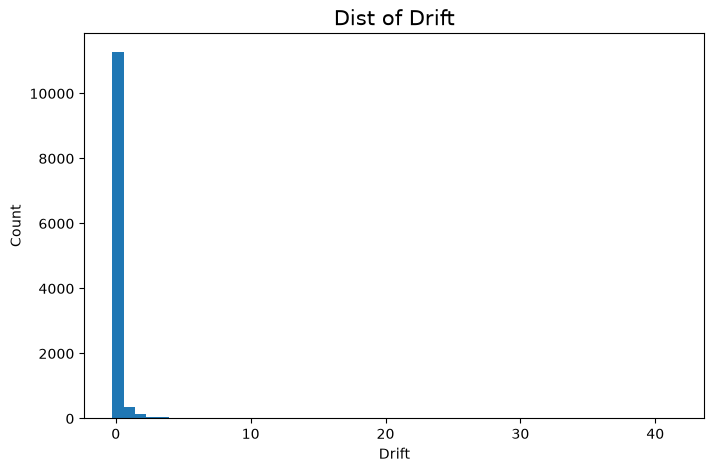

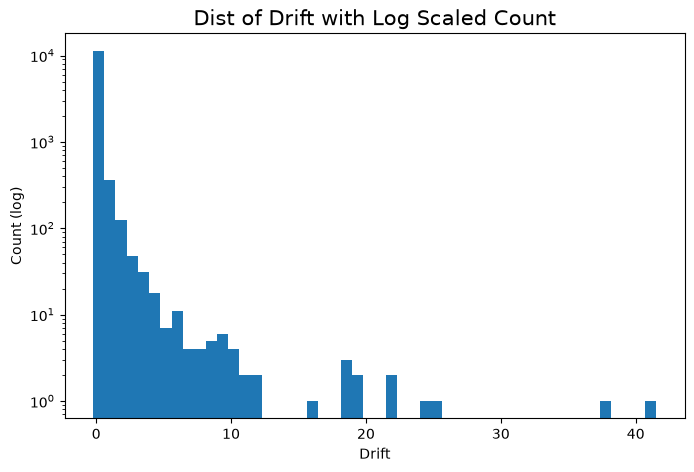

/var/folders/_5/c6lzttjj0cg6_d15t6wc96_r0000gn/T/ipykernel_45424/4061146492.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(newdata["Drift"], vert=False)


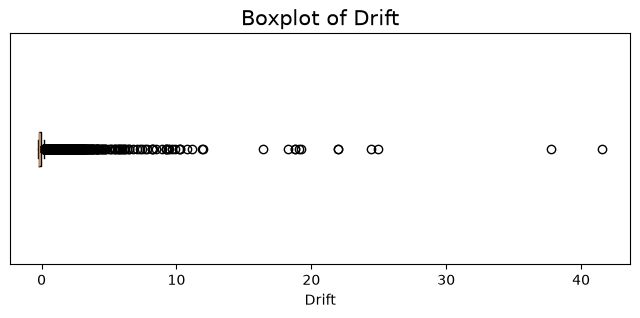

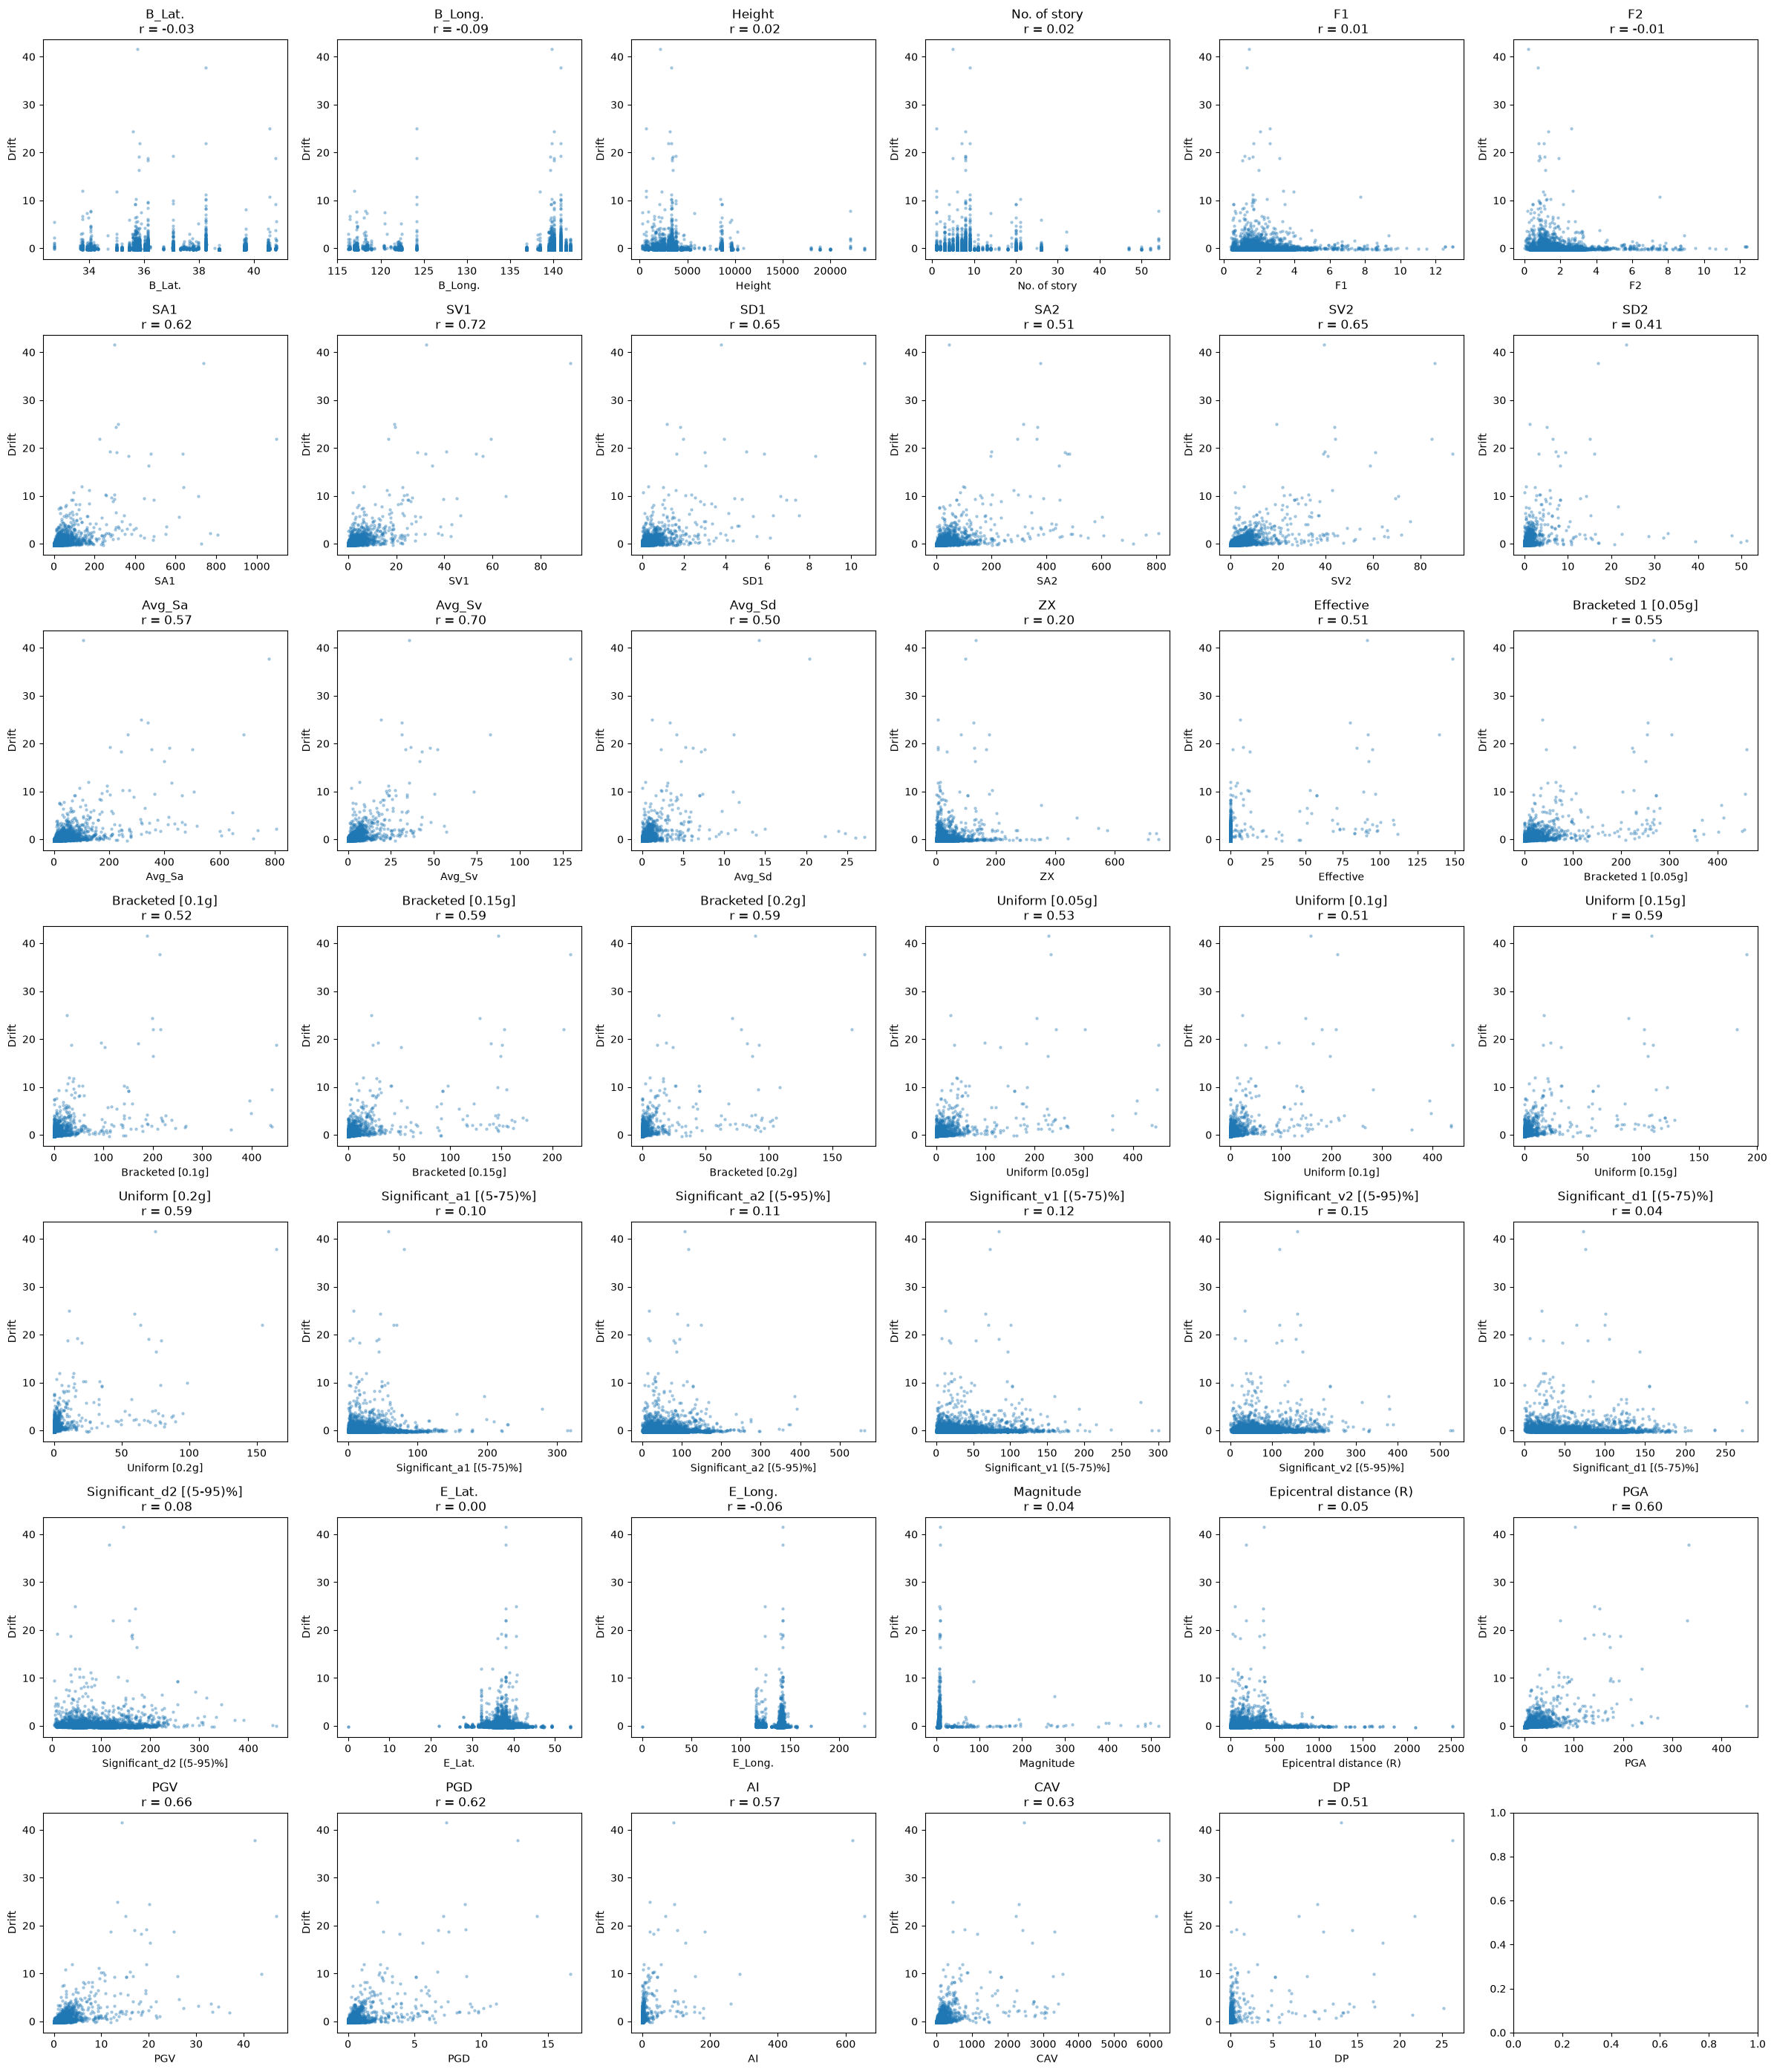

In [2]:
print(newdata["Drift"].describe())
print("Skew:", (newdata["Drift"].skew()))

#drift histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(newdata["Drift"], bins=50)
ax.set_title("Dist of Drift", size=15)
ax.set_xlabel("Drift")
ax.set_ylabel("Count")
plt.show()

# log scaling for count to make the tail visible
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(newdata["Drift"], bins=50)
ax.set_yscale("log")
ax.set_title("Dist of Drift with Log Scaled Count", size=15)
ax.set_xlabel("Drift")
ax.set_ylabel("Count (log)")
plt.show()





# drift boxplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(newdata["Drift"], vert=False)
ax.set_title("Boxplot of Drift", size=15)
ax.set_xlabel("Drift")
ax.set_yticks([])
plt.show()









# creating a scatterplot of each input feature with drift
fig, axs = plt.subplots(7, 6, figsize=(24, 28))
axs = axs.ravel()

for ax, feat in zip(axs, features):
    r = newdata[feat].corr(newdata["Drift"])
    ax.scatter(newdata[feat], newdata["Drift"], s=5, alpha=0.3)
    ax.set_title(f"{feat}\n r = {r:.2f}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Drift")

plt.tight_layout()
plt.show()

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?

Drift is very right-skewed, with a skew of about 19. Almost all records are bunched near the low end, with only about 20 above 10, and the largest is around 41. It also looks like Drift was already standardized, since the mean is about 0, the standard deviation is about 1, and the minimum is negative. So most earthquakes cause very little movement and only a handful cause large drift. Those rare large values matter the most for safety, but they will also be the hardest to predict.

Most scatterplots have a fan shape, where Drift stays near zero for low values of a feature and spreads out as the feature gets bigger. The most useful features are the shaking intensity measures. SV1 has the strongest correlation (r = 0.72), followed by Avg_Sv (0.70), PGV (0.66), SD1 and SV2 (0.65), CAV (0.63), SA1 and PGD (0.62), and PGA (0.60). The bracketed and uniform durations are also moderately related, at around 0.5 to 0.6. Building location, height, number of stories, F1, F2, epicentral distance, and the significant durations all have correlations close to zero.

Low correlation doesn't always mean a feature is useless, though, since correlation only picks up straight-line relationships. For example, the largest drifts only happen in buildings with low F1 and F2 and fewer than about 10 stories, which is a real pattern that r misses. Magnitude also has values up to 500, which isn't possible for an earthquake, so a few bad values are probably hiding its real relationship with Drift. This fits the paper, which found magnitude and f1 to be among the most important features, even though their correlations here are near zero.

## 3. SVR vs. Ridge Regression

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

X = newdata[features]
y = newdata["Drift"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Many spectral/duration/intensity features are heavily right-skewed and contain exact zeros,
# so log10 is not usable. Map skewed non-negative features to a normal shape with a quantile
# transform (fit on training data only, inside the pipeline), and standardize the rest.
skewed_cols = [c for c in features if X_train[c].skew() > 2 and X_train[c].min() >= 0]
other_cols = [c for c in features if c not in skewed_cols]
print(f"Quantile-transformed ({len(skewed_cols)}):", skewed_cols)

preprocess = ColumnTransformer([
    ("quant", QuantileTransformer(output_distribution="normal", random_state=42), skewed_cols),
    ("scale", StandardScaler(), other_cols),
])

svr_pipe = Pipeline([("prep", preprocess),
                     ("svr", SVR(cache_size=1000, max_iter=10_000, epsilon=0.01))])

svr_grid = {
    "svr__kernel": ["linear", "rbf", "poly"],
    "svr__C": [0.1, 1, 10],
}

svr_search = GridSearchCV(svr_pipe, svr_grid, cv=3, scoring="neg_mean_squared_error",
                          n_jobs=-1, verbose=1)
svr_search.fit(X_train, y_train)

svr_pred = svr_search.predict(X_test)
print("Best params:", svr_search.best_params_)
print("Test R2: ", round(r2_score(y_test, svr_pred), 4))
print("Test MSE:", round(mean_squared_error(y_test, svr_pred), 6))

Quantile-transformed (35): ['Height', 'No. of story', 'F1', 'F2', 'SA1', 'SV1', 'SD1', 'SA2', 'SV2', 'SD2', 'Avg_Sa', 'Avg_Sv', 'Avg_Sd', 'ZX', 'Effective', 'Bracketed 1 [0.05g]', 'Bracketed [0.1g]', 'Bracketed [0.15g]', 'Bracketed [0.2g]', 'Uniform [0.05g]', 'Uniform [0.1g]', 'Uniform [0.15g]', 'Uniform [0.2g]', 'Significant_a1 [(5-75)%]', 'Significant_a2 [(5-95)%]', 'Significant_v1 [(5-75)%]', 'Significant_v2 [(5-95)%]', 'Magnitude', 'Epicentral distance (R)', 'PGA', 'PGV', 'PGD', 'AI', 'CAV', 'DP']
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardS

Best params: {'svr__C': 10, 'svr__kernel': 'rbf'}
Test R2:  0.5535
Test MSE: 0.350854


b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [5]:
from sklearn.linear_model import Ridge

ridge_pipe = Pipeline([("prep", preprocess), ("ridge", Ridge())])

ridge_grid = {"ridge__alpha": np.logspace(-4, 4, 30)}

ridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
ridge_search.fit(X_train, y_train)

ridge_pred = ridge_search.predict(X_test)
print("Best alpha:", ridge_search.best_params_)
print("Test R2: ", round(r2_score(y_test, ridge_pred), 4))
print("Test MSE:", round(mean_squared_error(y_test, ridge_pred), 6))

Best alpha: {'ridge__alpha': np.float64(221.22162910704503)}
Test R2:  0.4766
Test MSE: 0.41132


c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

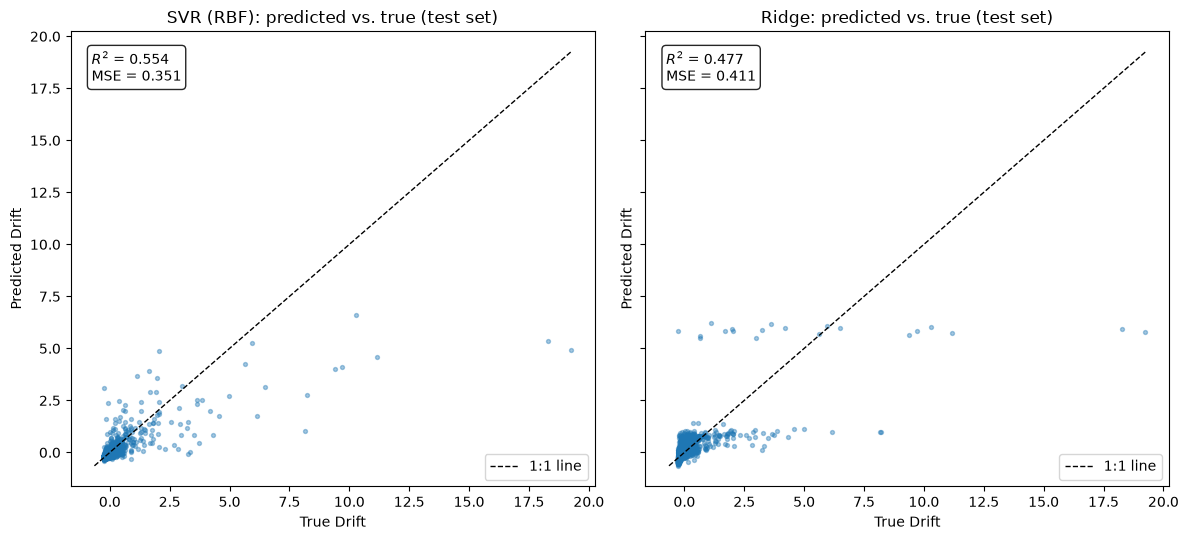

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
lo = min(y_test.min(), svr_pred.min(), ridge_pred.min())
hi = max(y_test.max(), svr_pred.max(), ridge_pred.max())

for ax, name, pred in [(axes[0], "SVR (RBF)", svr_pred), (axes[1], "Ridge", ridge_pred)]:
    ax.scatter(y_test, pred, s=8, alpha=0.4)
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1 line")
    ax.text(0.04, 0.96,
            f"$R^2$ = {r2_score(y_test, pred):.3f}\nMSE = {mean_squared_error(y_test, pred):.3f}",
            transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", fc="white", alpha=0.85))
    ax.set_title(f"{name}: predicted vs. true (test set)")
    ax.set_xlabel("True Drift"); ax.set_ylabel("Predicted Drift")
    ax.legend(loc="lower right")

plt.tight_layout(); plt.show()

SVR performed better than Ridge on the test set. It had an R² of 0.554 and an MSE of 0.351, compared to 0.477 and 0.411 for Ridge, so it explained more of the variation in Drift and had about 15% lower error.

The scatterplots show where the difference comes from. Both models underpredict the largest drifts, but SVR's predictions still rise as true Drift increases. Ridge's predictions mostly sit in two flat bands, one near 0 to 1 and another around 6, no matter what the true Drift is. That means Ridge is splitting the records into rough groups instead of following the actual trend. This makes sense because Ridge can only fit a straight line through the features, while the RBF kernel lets SVR fit curves and interactions, like how a building's height and frequency change its response to the same shaking. This matches the paper, which found SVR beat linear regression models.

Neither model is very accurate, though, since the best R² is only about 0.55. Our data mixes all building types, while the paper trained only on SRC buildings, and the few extreme drifts are very hard for either model to predict.

## 4. Feature Selection with Reduced SVR and Lasso

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error

required = ["X_train", "X_test", "y_train", "y_test", "svr_search", "ridge_search"]
missing = [v for v in required if v not in globals()]
assert not missing, f"Run Section 3 first. Missing: {missing}"

RANDOM_STATE = 42
if "cv" not in globals():
    cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

svr_full_pred_test = svr_search.predict(X_test)


def reg_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rel = (y_true - y_pred) / y_true
    return {
        "R2": r2_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "sigma": np.std(y_true - y_pred),
        "MARD": np.median(np.abs(rel)),
        "D10%": np.mean(np.abs(rel) <= 0.10) * 100,
    }


def plot_pred_true(ax, y_true, y_pred, title):
    m = reg_metrics(y_true, y_pred)
    ax.scatter(y_true, y_pred, s=12, alpha=0.5, edgecolor="none")
    lo = min(np.min(y_true), np.min(y_pred))
    hi = max(np.max(y_true), np.max(y_pred))
    line = np.linspace(lo, hi, 100)
    ax.plot(line, line, "k-", lw=1.5, label="1:1")
    ax.plot(line, line + m["sigma"], "r--", lw=1, label=r"$\pm 1\sigma$")
    ax.plot(line, line - m["sigma"], "r--", lw=1)
    ax.set_xlabel("True Drift")
    ax.set_ylabel("Predicted Drift")
    ax.set_title(title)
    ax.text(0.04, 0.96,
            f"$R^2$ = {m['R2']:.3f}\nMSE = {m['MSE']:.3e}\n"
            f"MARD = {m['MARD']:.3f}\n$D_{{10\\%}}$ = {m['D10%']:.1f}%",
            transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))
    ax.legend(loc="lower right")

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [8]:
K = 10

rsvr_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=K)),
        ("svr", SVR(cache_size=1000)),
    ]),
    transformer=StandardScaler(),
)

p = "regressor__svr__"
rsvr_param_grid = [
    {p + "kernel": ["linear"], p + "C": [0.1, 1, 10]},
    {p + "kernel": ["rbf"],    p + "C": [0.1, 1, 10, 100],
     p + "gamma": ["scale", 0.01, 0.1]},
    {p + "kernel": ["poly"],   p + "C": [0.1, 1, 10], p + "degree": [2, 3]},
]

rsvr_search = GridSearchCV(
    rsvr_model, rsvr_param_grid, cv=cv,
    scoring="neg_mean_squared_error", n_jobs=-1,
)
rsvr_search.fit(X_train, y_train)

print("Best reduced-SVR hyperparameters:",
      {k.replace(p, ""): v for k, v in rsvr_search.best_params_.items()})

selector = rsvr_search.best_estimator_.regressor_.named_steps["select"]
rsvr_features = list(X_train.columns[selector.get_support()])

corr_table = (X_train.corrwith(y_train).to_frame("r")
              .assign(abs_r=lambda d: d["r"].abs())
              .sort_values("abs_r", ascending=False))
corr_table["selected"] = corr_table.index.isin(rsvr_features)
print(f"\nSelected features ({K}):", rsvr_features)
display(corr_table.head(15))

paper_features = ["H", "N", "f1", "PGV", "PGD", "Dep", "M", "Sa1", "Sv1", "Sd1"]
sel_lower = {c.lower() for c in rsvr_features}
print("\nPaper's features also picked by correlation:",
      [f for f in paper_features if f.lower() in sel_lower])
print("Paper's features NOT picked by correlation:",
      [f for f in paper_features if f.lower() not in sel_lower])

rsvr_pred_train = rsvr_search.predict(X_train)
rsvr_pred_test = rsvr_search.predict(X_test)

Best reduced-SVR hyperparameters: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}

Selected features (10): ['SA1', 'SV1', 'SD1', 'SV2', 'Avg_Sv', 'Bracketed [0.2g]', 'Uniform [0.2g]', 'PGV', 'PGD', 'CAV']


,r,abs_r,selected
SV1,0.704836,0.704836,True
Avg_Sv,0.693743,0.693743,True
PGV,0.650243,0.650243,True
CAV,0.642912,0.642912,True
SD1,0.641695,0.641695,True
SV2,0.638288,0.638288,True
SA1,0.629936,0.629936,True
Bracketed [0.2g],0.614956,0.614956,True
PGD,0.614935,0.614935,True
Uniform [0.2g],0.614537,0.614537,True



Paper's features also picked by correlation: ['PGV', 'PGD', 'Sa1', 'Sv1', 'Sd1']
Paper's features NOT picked by correlation: ['H', 'N', 'f1', 'Dep', 'M']


,R2,MSE,sigma,MARD,D10%
SVR full - train,0.481056,0.572813,0.754204,0.209945,27.654217
SVR full - test,0.553545,0.350854,0.589677,0.236887,26.090604
SVR reduced (10) - train,0.865982,0.147930,0.384578,0.355019,5.612673
SVR reduced (10) - test,0.399449,0.471953,0.686932,0.356005,5.117450


Change in test R2 : -0.1541
Change in test MSE: +34.5 %


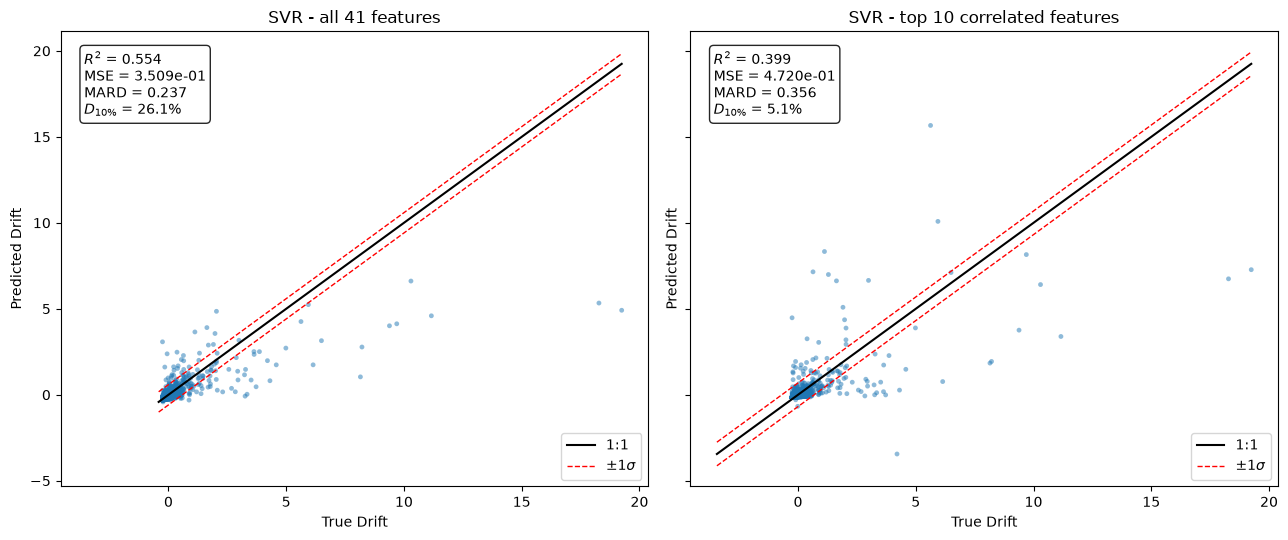

In [9]:
comparison_4a = pd.DataFrame({
    "SVR full - train": reg_metrics(y_train, svr_search.predict(X_train)),
    "SVR full - test": reg_metrics(y_test, svr_full_pred_test),
    f"SVR reduced ({K}) - train": reg_metrics(y_train, rsvr_pred_train),
    f"SVR reduced ({K}) - test": reg_metrics(y_test, rsvr_pred_test),
}).T
display(comparison_4a)

full_t = reg_metrics(y_test, svr_full_pred_test)
red_t = reg_metrics(y_test, rsvr_pred_test)
print(f"Change in test R2 : {red_t['R2'] - full_t['R2']:+.4f}")
print(f"Change in test MSE: {(red_t['MSE'] - full_t['MSE']) / full_t['MSE'] * 100:+.1f} %")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
plot_pred_true(axes[0], y_test, svr_full_pred_test, f"SVR - all {X_train.shape[1]} features")
plot_pred_true(axes[1], y_test, rsvr_pred_test, f"SVR - top {K} correlated features")
plt.tight_layout()
plt.show()

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

When we kept only the 10 features most correlated with Drift, the SVR got worse on the test set. Test R² dropped from 0.554 to 0.399, and test MSE went up from 0.351 to 0.472, which is about 34.5% higher. The reduced model also overfit. It had a train R² of 0.866 but a test R² of only 0.399, while the full model scored about the same on both (0.481 train and 0.554 test). We think the main problem is which features got picked. Almost all ten of them (SA1, SV1, SD1, SV2, Avg_Sv, PGV, PGD, CAV and two duration measures) describe how strongly the ground shook, so they mostly repeat the same information. The selection also left out building height, number of stories, the fundamental frequency f1, magnitude and epicentral distance, even though the paper found these important. The drop is much bigger than in the paper, where the reduced model was almost as accurate as the full one (σ of 0.213 vs 0.202). The authors picked their 10 features using SHAP values and by checking which ones are easy to get right after an earthquake, and correlation alone does neither of those things.

A smaller feature set is easier to use after a real earthquake. Most buildings have no sensors inside them, so the model works best when it only needs data that is available quickly, like magnitude, distance and ground motion from regional stations, plus building details that are already on record. Fewer inputs also means less data to collect, lower cost, and faster training and prediction. However, our correlation-based selection picked SV2 and Avg_Sv, which depend on f2 and need sensors inside the building. This is why the paper chose features based on how easy they are to get, not only on correlation.

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

They only partly select the same features. Lasso kept 8 features, and 4 of them match the reduced SVR (SV1, SD1, PGD and Avg_Sv). The reduced SVR also picked SA1, SV2, PGV, CAV and two duration measures, while Lasso picked DP, Arias intensity, building longitude and a duration measure with a coefficient close to zero. The difference comes from how each method chooses. Correlation looks at each feature on its own, so it picked many features that measure the same shaking. Lasso looks at the features together, so once it had SV1, which has by far the largest coefficient, it dropped similar features like SA1 and PGV because they added little new information.

Lasso performed much better than the reduced SVR, with a test R² of 0.613 compared to 0.399 and a test MSE of 0.304 compared to 0.472. It even did slightly better than the full SVR (R² of 0.554). One reason is that Lasso chose less redundant features. Another is that the reduced SVR overfit the training data. The relationship between Drift and SV1 may also be close to linear, so the extra flexibility of the RBF kernel did not help much. This is different from the paper, where SVR beat the simpler models, but the authors used only one building type and chose their features differently.

Best Lasso alpha: 3.0323e-02
Lasso kept 8 of 41 features

Selected by BOTH           : ['Avg_Sv', 'PGD', 'SD1', 'SV1']
Only reduced SVR (corr.)   : ['Bracketed [0.2g]', 'CAV', 'PGV', 'SA1', 'SV2', 'Uniform [0.2g]']
Only Lasso                 : ['AI', 'B_Long.', 'DP', 'Significant_v2 [(5-95)%]']


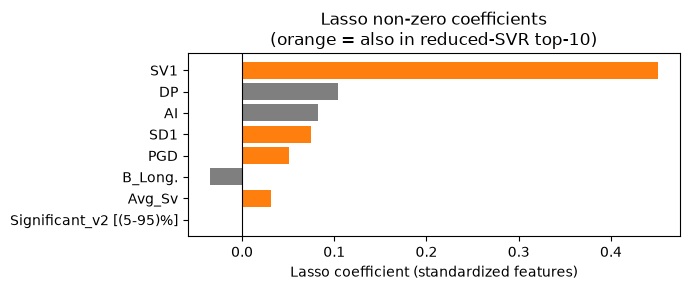

In [10]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=100_000)),
])

Xs = StandardScaler().fit_transform(X_train)
alpha_max = np.max(np.abs(Xs.T @ (y_train - y_train.mean()))) / len(y_train)
lasso_param_grid = {"lasso__alpha": alpha_max * np.logspace(-4, 0, 50)}

lasso_search = GridSearchCV(
    lasso_model, lasso_param_grid, cv=cv,
    scoring="neg_mean_squared_error", n_jobs=-1,
)
lasso_search.fit(X_train, y_train)

print(f"Best Lasso alpha: {lasso_search.best_params_['lasso__alpha']:.4e}")

coefs = pd.Series(lasso_search.best_estimator_.named_steps["lasso"].coef_,
                  index=X_train.columns)
lasso_features = list(coefs[coefs != 0].index)
print(f"Lasso kept {len(lasso_features)} of {X_train.shape[1]} features")

lasso_pred_test = lasso_search.predict(X_test)

set_svr, set_lasso = set(rsvr_features), set(lasso_features)
print("\nSelected by BOTH           :", sorted(set_svr & set_lasso))
print("Only reduced SVR (corr.)   :", sorted(set_svr - set_lasso))
print("Only Lasso                 :", sorted(set_lasso - set_svr))

nz = coefs[coefs != 0].sort_values(key=np.abs)
fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(nz))))
ax.barh(nz.index, nz.values,
        color=["tab:orange" if f in set_svr else "tab:gray" for f in nz.index])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Lasso coefficient (standardized features)")
ax.set_title("Lasso non-zero coefficients\n(orange = also in reduced-SVR top-10)")
plt.tight_layout()
plt.show()

,R2,MSE,sigma,MARD,D10%
SVR reduced (10 feat.),0.399449,0.471953,0.686932,0.356005,5.117450
Lasso (8 non-zero feat.),0.613318,0.303881,0.551232,0.217635,33.263423
SVR full [reference],0.553545,0.350854,0.589677,0.236887,26.090604


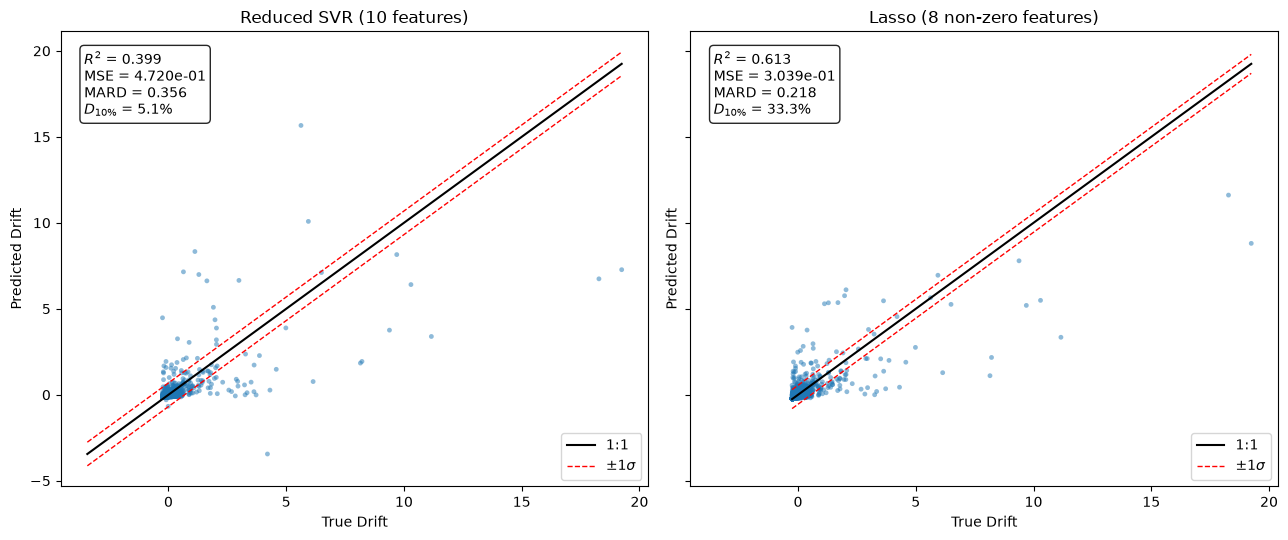

In [11]:
comparison_4b = pd.DataFrame({
    f"SVR reduced ({K} feat.)": reg_metrics(y_test, rsvr_pred_test),
    f"Lasso ({len(lasso_features)} non-zero feat.)": reg_metrics(y_test, lasso_pred_test),
    "SVR full [reference]": reg_metrics(y_test, svr_full_pred_test),
}).T
display(comparison_4b)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
plot_pred_true(axes[0], y_test, rsvr_pred_test, f"Reduced SVR ({K} features)")
plot_pred_true(axes[1], y_test, lasso_pred_test,
               f"Lasso ({len(lasso_features)} non-zero features)")
plt.tight_layout()
plt.show()

## 5. Robustness to Training Data Changes

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

Ridge was much more stable than SVR. After removing 10 random training points, Ridge's predictions changed by about 0.0009 standard deviations on average across 30 runs, while SVR's changed by about 0.033, which is roughly 40 times more. SVR changed less than Ridge in none of the 30 runs. Still, both changes are small, since SVR's predictions only moved about 3% of the spread in Drift.

We expected SVR to be more stable, because its fit only depends on the support vectors and each point's influence is capped by C. That did not happen here for two reasons. First, 56% of the training points (5,297 of 9,532) were support vectors, so most removed points still affected the fit. Second, the RBF kernel makes a flexible fit that bends around nearby points, so losing a few support vectors reshapes the curve in that area. Ridge is a simple linear model fit on all 9,532 points at once, so removing 10 of them barely moves its coefficients.

In [12]:
svr_base = svr_search.best_estimator_
ridge_base = ridge_search.best_estimator_

pred_svr_0 = svr_base.predict(X_test)
pred_ridge_0 = ridge_base.predict(X_test)


def find_svr(est):
    if isinstance(est, SVR):
        return est
    if hasattr(est, "regressor_"):
        return find_svr(est.regressor_)
    if hasattr(est, "steps"):
        return find_svr(est.steps[-1][1])
    raise ValueError("No SVR found")


def prediction_change(pred_before, pred_after):
    diff = np.abs(pred_after - pred_before)
    return {
        "mean |change|": diff.mean(),
        "max |change|": diff.max(),
        "mean |change| / std(y_test)": diff.mean() / np.std(y_test),
    }


def remove_and_refit(seed, n_remove=10):
    rng = np.random.default_rng(seed)
    drop_pos = rng.choice(len(X_train), size=n_remove, replace=False)
    keep = np.setdiff1d(np.arange(len(X_train)), drop_pos)
    X_red, y_red = X_train.iloc[keep], y_train.iloc[keep]

    svr_new = clone(svr_base).fit(X_red, y_red)
    ridge_new = clone(ridge_base).fit(X_red, y_red)

    n_sv_removed = np.isin(drop_pos, find_svr(svr_base).support_).sum()
    return svr_new.predict(X_test), ridge_new.predict(X_test), n_sv_removed


pred_svr_1, pred_ridge_1, n_sv_removed = remove_and_refit(seed=RANDOM_STATE)

n_sv = len(find_svr(svr_base).support_)
print(f"Original SVR: {n_sv} support vectors out of {len(X_train)} training points "
      f"({n_sv / len(X_train):.0%})")
print(f"Removed points that were support vectors: {n_sv_removed} / 10\n")

single_run = pd.DataFrame({
    "SVR": prediction_change(pred_svr_0, pred_svr_1),
    "Ridge": prediction_change(pred_ridge_0, pred_ridge_1),
}).T
display(single_run)

/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Original SVR: 5297 support vectors out of 9532 training points (56%)
Removed points that were support vectors: 4 / 10



,mean |change|,max |change|,mean |change| / std(y_test)
SVR,0.036416,0.132260,0.041078
Ridge,0.000187,0.001359,0.000211


/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/haydenwillen/Desktop/Machine Learning II/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardS

,mean,std,min,max
SVR,0.033037,0.008283,0.014070,0.051171
Ridge,0.000868,0.001300,0.000217,0.006752


SVR changed less than Ridge in 0% of 30 runs


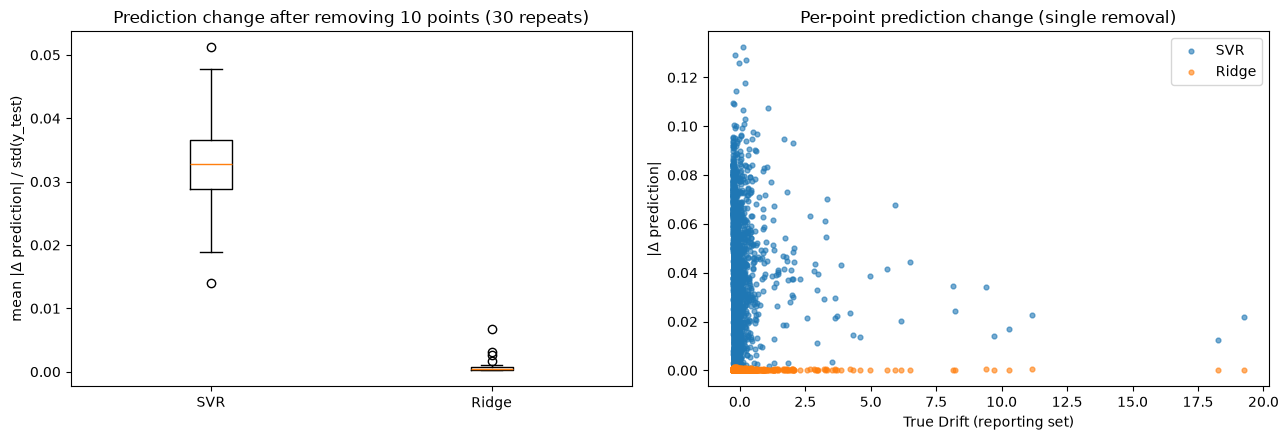

,mean SVR change
SVs removed,
4,0.033322
5,0.032950
6,0.038723
7,0.033292
8,0.018951
9,0.027616


In [13]:
N_REPEATS = 30
rows = []
for seed in range(N_REPEATS):
    ps, pr, nsv = remove_and_refit(seed)
    rows.append({
        "seed": seed,
        "SVR": np.mean(np.abs(ps - pred_svr_0)) / np.std(y_test),
        "Ridge": np.mean(np.abs(pr - pred_ridge_0)) / np.std(y_test),
        "SVs removed": nsv,
    })
repeats = pd.DataFrame(rows)

display(repeats[["SVR", "Ridge"]].describe().T[["mean", "std", "min", "max"]])
print(f"SVR changed less than Ridge in "
      f"{(repeats['SVR'] < repeats['Ridge']).mean():.0%} of {N_REPEATS} runs")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].boxplot([repeats["SVR"], repeats["Ridge"]])
axes[0].set_xticks([1, 2], ["SVR", "Ridge"])
axes[0].set_ylabel("mean |Δ prediction| / std(y_test)")
axes[0].set_title(f"Prediction change after removing 10 points ({N_REPEATS} repeats)")

axes[1].scatter(y_test, np.abs(pred_svr_1 - pred_svr_0), s=12, alpha=0.6, label="SVR")
axes[1].scatter(y_test, np.abs(pred_ridge_1 - pred_ridge_0), s=12, alpha=0.6, label="Ridge")
axes[1].set_xlabel("True Drift (reporting set)")
axes[1].set_ylabel("|Δ prediction|")
axes[1].set_title("Per-point prediction change (single removal)")
axes[1].legend()
plt.tight_layout()
plt.show()

if repeats["SVs removed"].nunique() > 1:
    display(repeats.groupby("SVs removed")["SVR"].mean().to_frame("mean SVR change"))